<a href="https://www.kaggle.com/code/sonawanelalitsunil/ev-growth-trends-ml-100?scriptVersionId=233959152" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/electric-vehicle-population/Electric_Vehicle_Population_Data.csv


## Title:  EV Growth Trends

###  Description: Tracking the rise of electric vehicles over time.

## Import Dataset

In [2]:
df = pd.read_csv('/kaggle/input/electric-vehicle-population/Electric_Vehicle_Population_Data.csv')

In [3]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,98370.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,23.0,109705683,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
2,KM8KRDAF5P,Kitsap,Olalla,WA,98359.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,26.0,230390492,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,5.303509e+10
3,5UXTA6C0XM,Kitsap,Seabeck,WA,98380.0,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,0.0,35.0,267929112,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC,5.303509e+10
4,JTMAB3FV7P,Thurston,Rainier,WA,98576.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,236505139,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


In [4]:
df.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
235687,1C4RJXN62R,Pierce,Tacoma,WA,98407.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,27.0,267004272,POINT (-122.51134 47.29238),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305306e+10
235688,5YJSA1E28J,Snohomish,Stanwood,WA,98292.0,2018,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,249.0,0.0,10.0,198794410,POINT (-122.37265 48.24159),BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,5.306105e+10
235689,3FA6P0SU2F,King,Redmond,WA,98052.0,2015,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,0.0,48.0,261742288,POINT (-122.13158 47.67858),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
235690,WA1BCBFZ6P,Snohomish,Lake Stevens,WA,98258.0,2023,AUDI,Q4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,44.0,253474854,POINT (-122.06402 48.01497),PUGET SOUND ENERGY INC,5.306105e+10
235691,WBY33AW03P,King,Issaquah,WA,98027.0,2023,BMW,I4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,5.0,229583490,POINT (-122.03439 47.5301),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235692 entries, 0 to 235691
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         235692 non-null  object 
 1   County                                             235689 non-null  object 
 2   City                                               235689 non-null  object 
 3   State                                              235692 non-null  object 
 4   Postal Code                                        235689 non-null  float64
 5   Model Year                                         235692 non-null  int64  
 6   Make                                               235692 non-null  object 
 7   Model                                              235692 non-null  object 
 8   Electric Vehicle Type                              235692 non-null  object

In [6]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,235689.000000,235692.000000,235656.000000,235656.000000,235198.000000,2.356920e+05,2.356890e+05
mean,98177.656463,2021.406658,46.262569,787.268328,28.879519,2.353127e+08,5.298066e+10
std,2524.218661,2.991908,84.045829,7177.668305,14.904644,6.799098e+07,1.521066e+09
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,17.000000,2.053457e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,0.000000,32.000000,2.522795e+08,5.303303e+10
75%,98374.000000,2024.000000,38.000000,0.000000,42.000000,2.696401e+08,5.305307e+10
max,99577.000000,2025.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.602100e+10


In [7]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        36
Base MSRP                                             36
Legislative District                                 494
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       3
2020 Census Tract                                      3
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract       

In [10]:
df.shape

(235692, 17)

In [11]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

## Data visualizations

In [12]:
import plotly.express as px

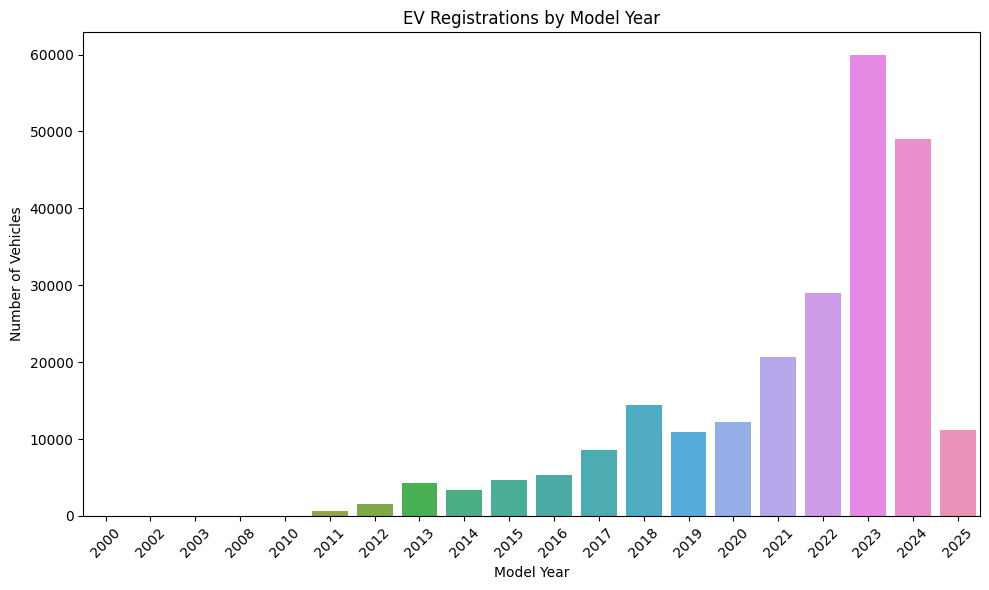

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Model Year', order=sorted(df['Model Year'].dropna().unique()))
plt.title("EV Registrations by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


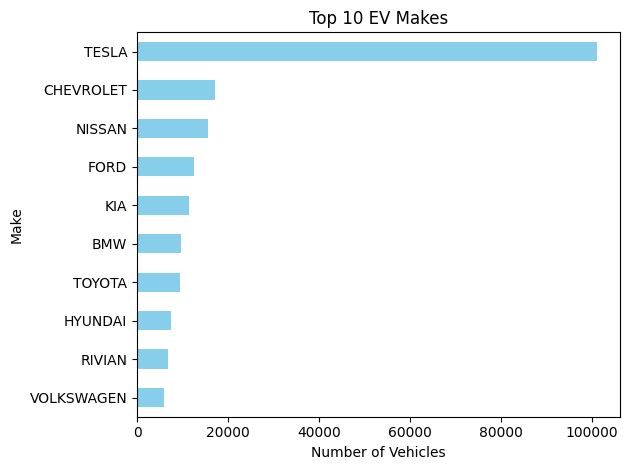

In [14]:
top_makes = df['Make'].value_counts().head(10)
top_makes.plot(kind='barh', color='skyblue')
plt.title("Top 10 EV Makes")
plt.xlabel("Number of Vehicles")
plt.ylabel("Make")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


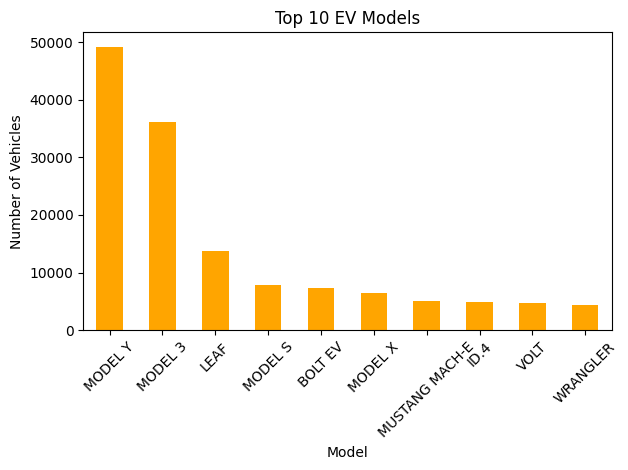

In [15]:
top_models = df['Model'].value_counts().head(10)
top_models.plot(kind='bar', color='orange')
plt.title("Top 10 EV Models")
plt.xlabel("Model")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


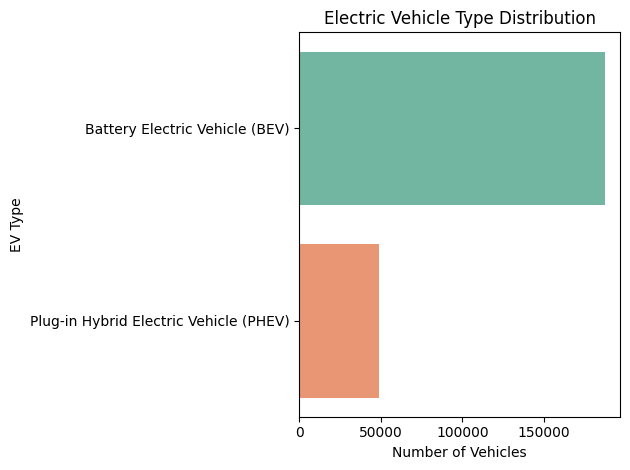

In [16]:
sns.countplot(data=df, y='Electric Vehicle Type', order=df['Electric Vehicle Type'].value_counts().index, palette='Set2')
plt.title("Electric Vehicle Type Distribution")
plt.xlabel("Number of Vehicles")
plt.ylabel("EV Type")
plt.tight_layout()
plt.show()


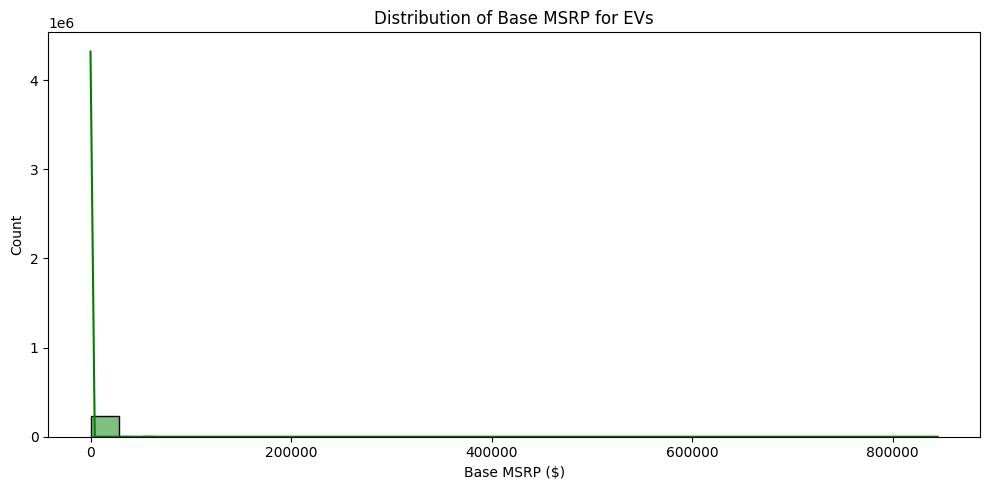

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Base MSRP', bins=30, kde=True, color='green')
plt.title("Distribution of Base MSRP for EVs")
plt.xlabel("Base MSRP ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


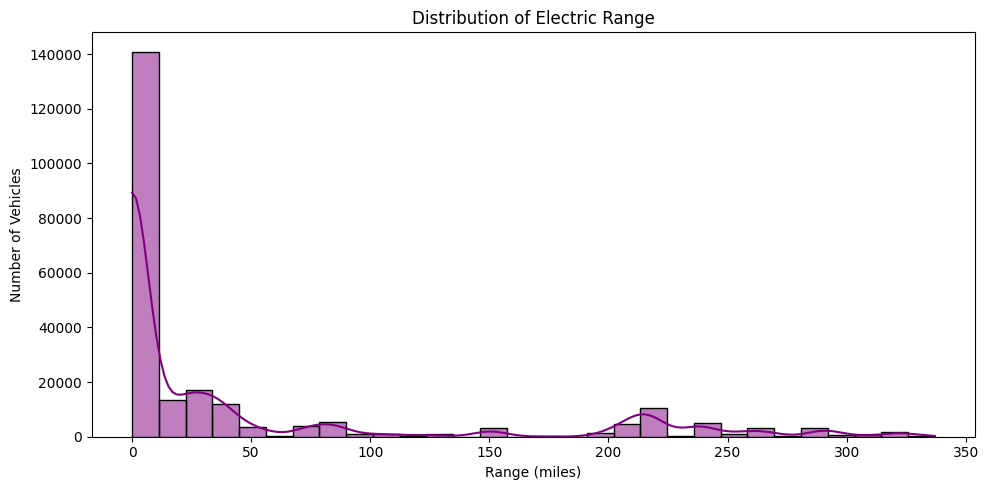

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Electric Range', bins=30, kde=True, color='purple')
plt.title("Distribution of Electric Range")
plt.xlabel("Range (miles)")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()


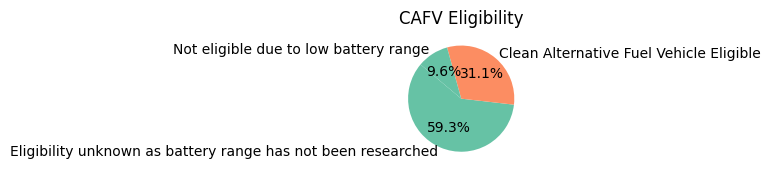

In [19]:
cafv_counts = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
cafv_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, figsize=(6,6), colors=['#66c2a5','#fc8d62'])
plt.title("CAFV Eligibility")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [20]:
county_counts = df['County'].value_counts().reset_index()
county_counts.columns = ['County', 'EV Count']

fig = px.choropleth(county_counts,
                    locations='County',
                    locationmode='USA-states',
                    color='EV Count',
                    scope="usa",
                    title="EV Count by County")
fig.show()


## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

In [23]:
df = df.dropna(subset=["Clean Alternative Fuel Vehicle (CAFV) Eligibility"])

In [24]:
# Define target
df['Target'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(lambda x: 1 if 'Eligible' in x else 0)


In [25]:
# Separate features and target
y = df['Electric Vehicle Type']  # or another target column
X = df.drop(columns=['Electric Vehicle Type'])

# Handle categorical columns
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype(str)

# Impute missing values
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# Encode categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target
y = LabelEncoder().fit_transform(y)

# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}


===== Logistic Regression =====
Accuracy: 0.9975816203143894
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     37527
           1       0.99      1.00      0.99      9612

    accuracy                           1.00     47139
   macro avg       1.00      1.00      1.00     47139
weighted avg       1.00      1.00      1.00     47139



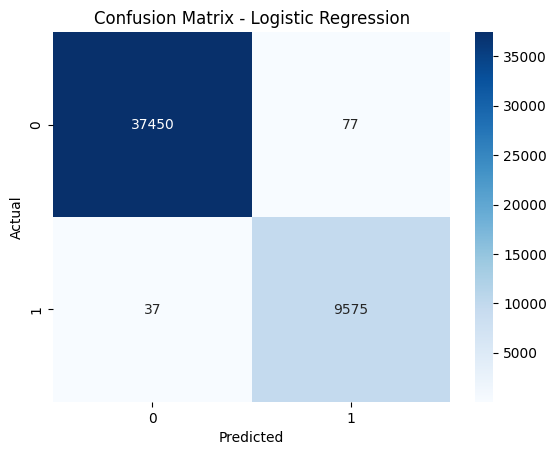


===== Decision Tree =====
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     37527
           1       1.00      1.00      1.00      9612

    accuracy                           1.00     47139
   macro avg       1.00      1.00      1.00     47139
weighted avg       1.00      1.00      1.00     47139



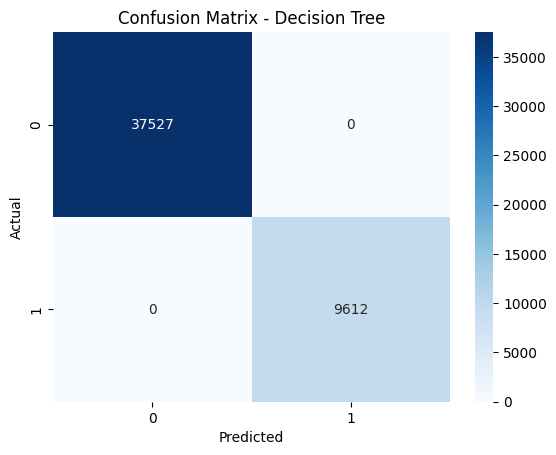


===== Random Forest =====
Accuracy: 0.9999575722862174
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     37527
           1       1.00      1.00      1.00      9612

    accuracy                           1.00     47139
   macro avg       1.00      1.00      1.00     47139
weighted avg       1.00      1.00      1.00     47139



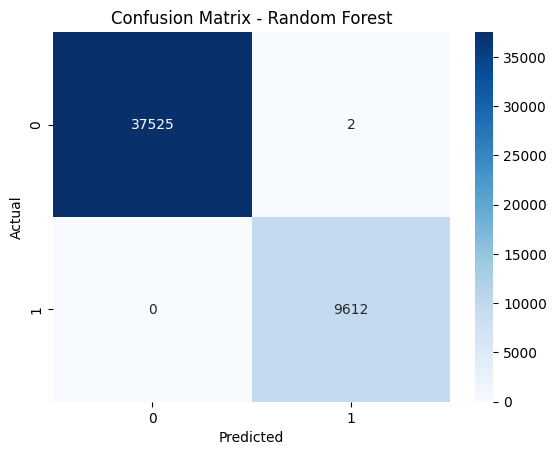


===== Naive Bayes =====
Accuracy: 0.9636606631451664
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     37527
           1       0.96      0.86      0.91      9612

    accuracy                           0.96     47139
   macro avg       0.96      0.92      0.94     47139
weighted avg       0.96      0.96      0.96     47139



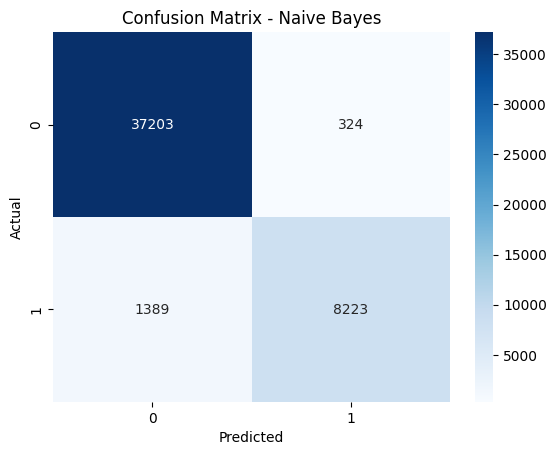


===== SVM =====
Accuracy: 0.9976664757419547
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     37527
           1       0.99      1.00      0.99      9612

    accuracy                           1.00     47139
   macro avg       0.99      1.00      1.00     47139
weighted avg       1.00      1.00      1.00     47139



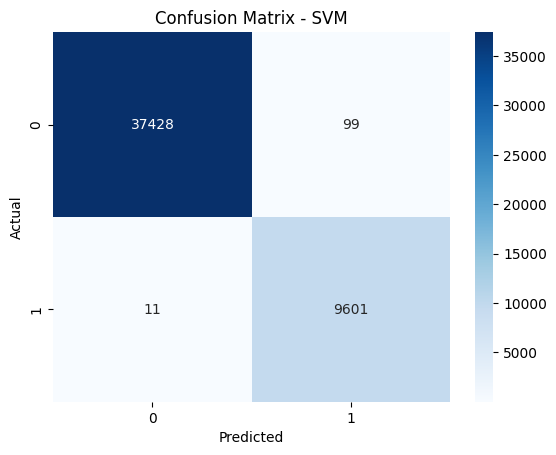


===== KNN =====
Accuracy: 0.9967542798956278
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     37527
           1       0.99      0.99      0.99      9612

    accuracy                           1.00     47139
   macro avg       0.99      1.00      1.00     47139
weighted avg       1.00      1.00      1.00     47139



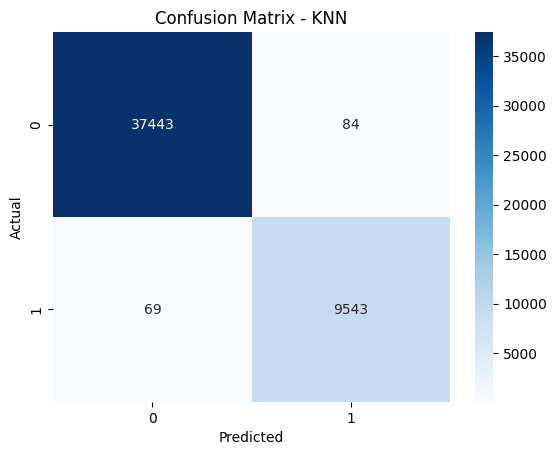

In [28]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Thank you...pls upvote!!!!